In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
print(df.shape)

(9994, 21)


In [3]:
# check missing values and duplicates
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

# clean
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("\nData cleaned successfully!")

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicates: 0

Data cleaned successfully!


In [4]:
# Total Sales and Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02


In [5]:
# Top 5 Products by Sales
top5 = df.groupby('Product Name')['Sales'].sum().nlargest(5)
print(top5)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


In [6]:
# Monthly Sales Trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()
print(monthly)

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

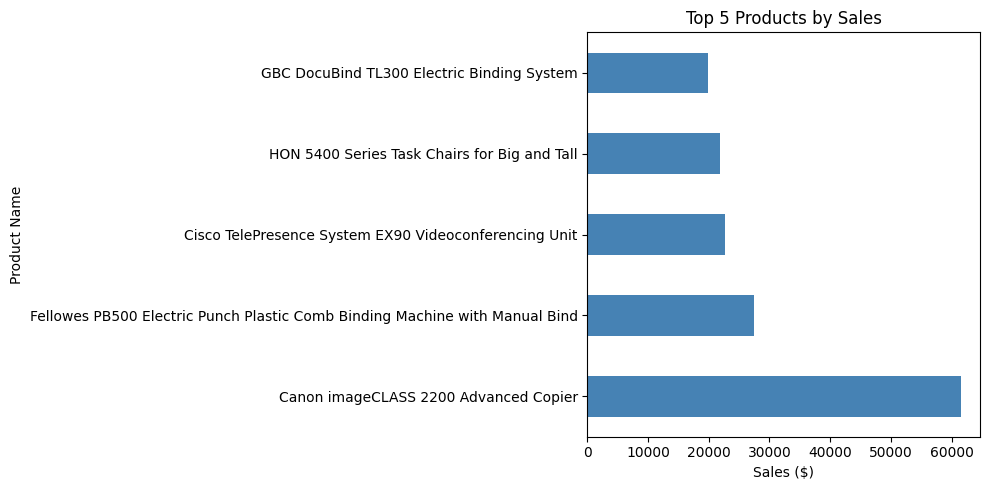

In [7]:
# Chart 1 - Top 5 Products by Sales
top5.plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Top 5 Products by Sales')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.savefig('chart1_top5.png')
plt.show()

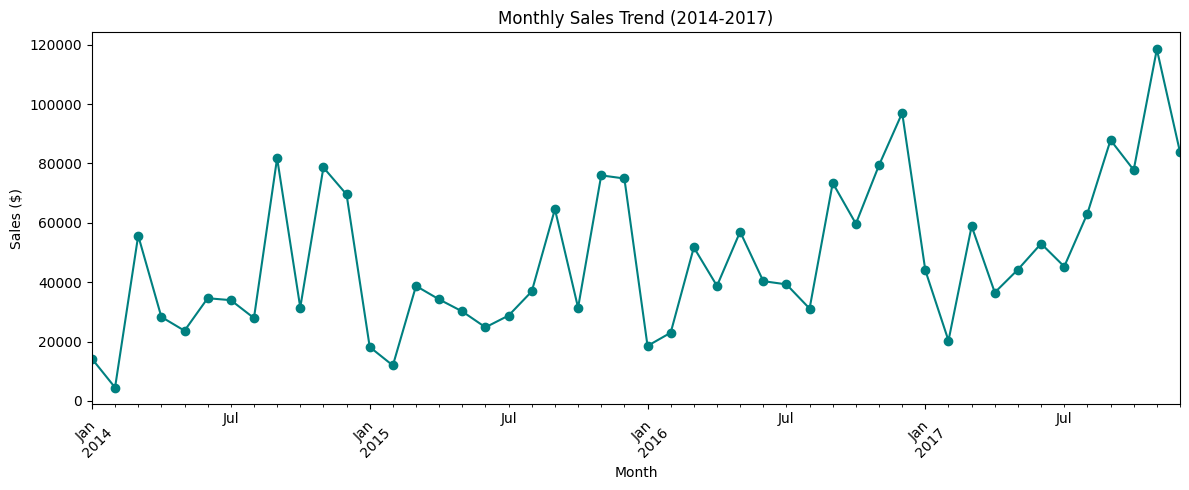

In [8]:
# Chart 2 - Monthly Sales Trend
monthly.plot(figsize=(12, 5), marker='o', color='teal')
plt.title('Monthly Sales Trend (2014-2017)')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_monthly.png')
plt.show()

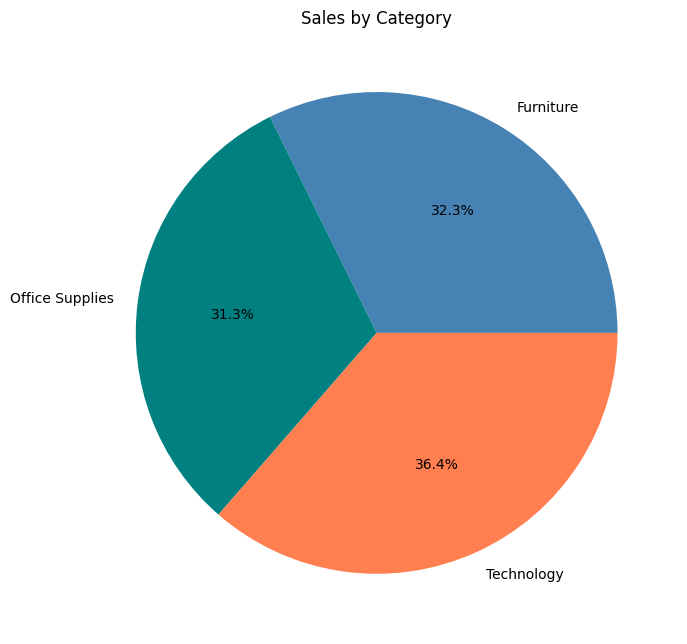

In [9]:
# Chart 3 - Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum()
cat_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7), colors=['steelblue', 'teal', 'coral'])
plt.title('Sales by Category')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3_category.png')
plt.show()

In [10]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("Sales by Region:")
print(region_sales)

Sales by Region:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [11]:
# Sales by Category
print("\nSales by Category:")
print(cat_sales)


Sales by Category:
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


In [12]:
# Profit Margin
profit_margin = (total_profit / total_sales) * 100
print(f"\nProfit Margin: {profit_margin:.2f}%")


Profit Margin: 12.47%
